# Final Assignment Set B — Regression track (Concrete Compressive Strength)

## Machine Learning Lab, Summer Semester 2026, Uni Passau

*Split from `final-assignment/SetB.ipynb`: this notebook keeps only the **regression** track (Concrete Compressive Strength — LinearRegression/Ridge baseline + ANN). See `breast_cancer_classification.ipynb` for the Breast Cancer classification track.*

### Rules:

   1. Submissions must be pushed to your fimgit in a folder dubbed `final-assignment`.
   2. Run your solutions in cells under the individual Tasks.
   3. For model implementations you are permitted to use *only* your library in its final state before the commencement of the exam.

Goodluck!

---


### Task 1: Prepare your data

   1. Download the two datasets and read them into memory.

   2. Analyse the data shape, targets and data characteristics.

   3. Apply any data cleaning, filling mechanisms if required

   4. Split the datasets into `train`, `valid` and `test` folds.

Dataset 1: [CLASSIFICATION] Breast Cancer: https://archive.ics.uci.edu/dataset/14/breast+cancer

Dataset 2: [REGRESSION] Concrete Compressive Strength: https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength


> Note: You may obtain the data any way you like from its UCI page

#### Imports & environment setup


In [1]:
# ---- Task 1: Imports & environment setup ----
# Data handling / plotting / preprocessing libraries. The MODELS (Tasks 2 & 4) come exclusively from our
# own `mlab` library, as required by the rules; scikit-learn is used ONLY for scaling/preprocessing.
import sys, subprocess, importlib

def _ensure(pkg, module=None):
    """Import `module` (defaults to `pkg`); pip-install `pkg` first if missing.
    Keeps the notebook self-contained/reproducible for the grader on any kernel."""
    try:
        return importlib.import_module(module or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        return importlib.import_module(module or pkg)

_ensure("ucimlrepo")
_ensure("matplotlib")
_ensure("scikit-learn", "sklearn")
_ensure("imbalanced-learn", "imblearn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold

print("Imports ready:  numpy", np.__version__, "| pandas", pd.__version__)


Imports ready:  numpy 2.4.4 | pandas 3.0.2


#### Load the Concrete dataset

In [2]:
# ---- Task 1.1  Concrete Compressive Strength [REGRESSION]: download & read into memory ----
# UCI id 165.
concrete = fetch_ucirepo(id=165)
conc_X = concrete.data.features
conc_y = concrete.data.targets
conc_target = conc_y.columns[0]

print("Concrete Compressive Strength (regression)")
print("  features:", conc_X.shape, "| targets:", conc_y.shape)
print("  columns :", list(conc_X.columns))
display(conc_X.head())
display(conc_y.head())


Concrete Compressive Strength (regression)
  features: (1030, 8) | targets: (1030, 1)
  columns : ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


#### Explore & visualize the Concrete data

In [3]:
# ---- Task 1.2  Concrete: analysis & visualization ----
n, d = conc_X.shape
print(f"Samples: {n}  |  Features: {d} (all numeric)")
miss = conc_X.isna().sum(); miss = miss[miss > 0]
print("Missing values :", miss.to_dict() if len(miss) else "none")
print("Duplicate rows :", int(conc_X.duplicated().sum()))

# zero-inflation: several mix components are "not used" (exactly 0) in many samples
zero_pct = (conc_X == 0).mean().mul(100).round(1)
print("\n% exact-zero values per feature (structural 'not in mix', NOT missing):")
print(zero_pct[zero_pct > 0].to_dict())

print("\nTarget distribution:")
tdesc = conc_y[conc_target].describe()
print(f"  min={tdesc['min']:.2f}  mean={tdesc['mean']:.2f}  median={conc_y[conc_target].median():.2f}"
      f"  max={tdesc['max']:.2f}  std={tdesc['std']:.2f}  skew={conc_y[conc_target].skew():.2f}")
print("\nFeature summary statistics:")
display(conc_X.describe().T.round(2))

# linear (Pearson) vs rank (Spearman) correlation -> rank >> linear reveals non-linearity
t = conc_y[conc_target]
corr = pd.DataFrame({
    "pearson":  {c: conc_X[c].corr(t) for c in conc_X.columns},
    "spearman": {c: conc_X[c].rank().corr(t.rank()) for c in conc_X.columns},
})
corr["nonlinear_gap"] = corr["spearman"].abs() - corr["pearson"].abs()
print("Correlation with target (large positive nonlinear_gap => non-linear relationship):")
display(corr.round(3).sort_values("pearson", key=lambda s: s.abs(), ascending=False))


Samples: 1030  |  Features: 8 (all numeric)
Missing values : none
Duplicate rows : 38

% exact-zero values per feature (structural 'not in mix', NOT missing):
{'Blast Furnace Slag': 45.7, 'Fly Ash': 55.0, 'Superplasticizer': 36.8}

Target distribution:
  min=2.33  mean=35.82  median=34.45  max=82.60  std=16.71  skew=0.42

Feature summary statistics:


,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.17,104.51,102.0,192.38,272.9,350.00,540.0
Blast Furnace Slag,1030.0,73.90,86.28,0.0,0.00,22.0,142.95,359.4
Fly Ash,1030.0,54.19,64.00,0.0,0.00,0.0,118.30,200.1
Water,1030.0,181.57,21.35,121.8,164.90,185.0,192.00,247.0
Superplasticizer,1030.0,6.20,5.97,0.0,0.00,6.4,10.20,32.2
Coarse Aggregate,1030.0,972.92,77.75,801.0,932.00,968.0,1029.40,1145.0
Fine Aggregate,1030.0,773.58,80.18,594.0,730.95,779.5,824.00,992.6
Age,1030.0,45.66,63.17,1.0,7.00,28.0,56.00,365.0


Correlation with target (large positive nonlinear_gap => non-linear relationship):


,pearson,spearman,nonlinear_gap
Cement,0.498,0.478,-0.020
Superplasticizer,0.366,0.348,-0.018
Age,0.329,0.596,0.267
Water,-0.290,-0.308,0.019
Fine Aggregate,-0.167,-0.180,0.013
Coarse Aggregate,-0.165,-0.184,0.019
Blast Furnace Slag,0.135,0.164,0.029
Fly Ash,-0.106,-0.078,-0.028


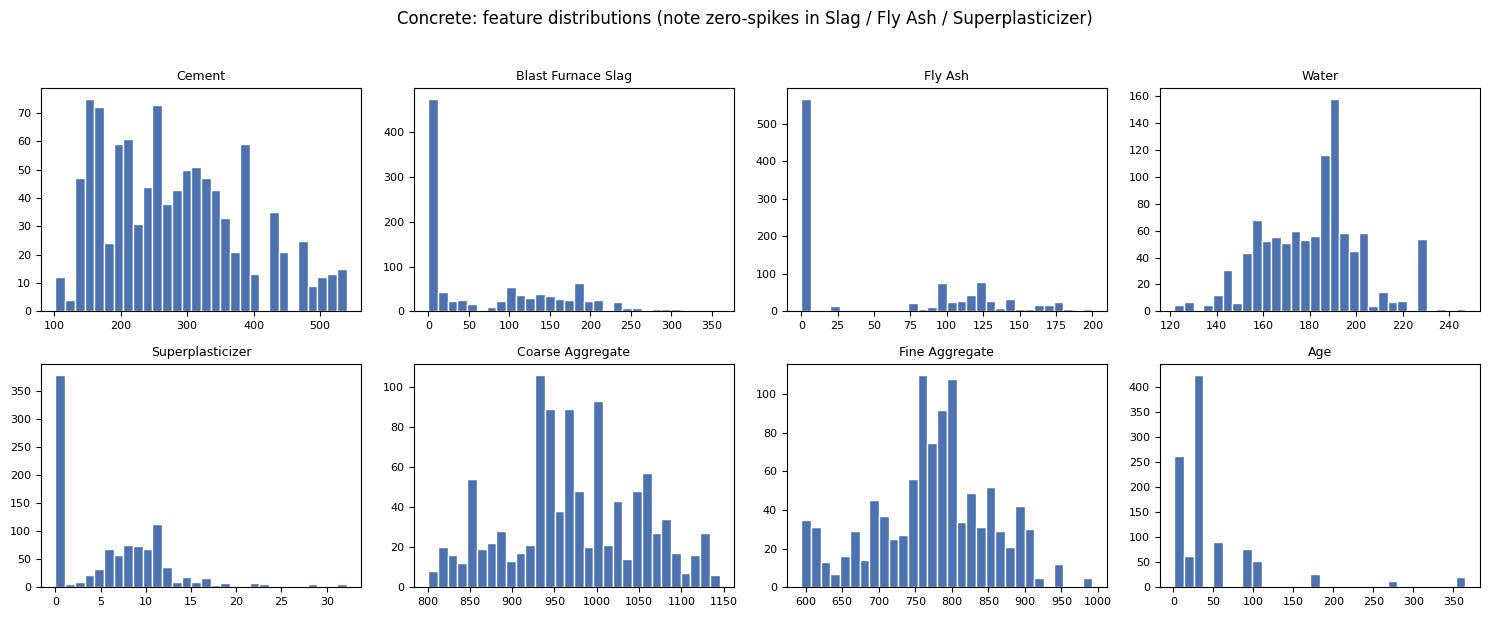

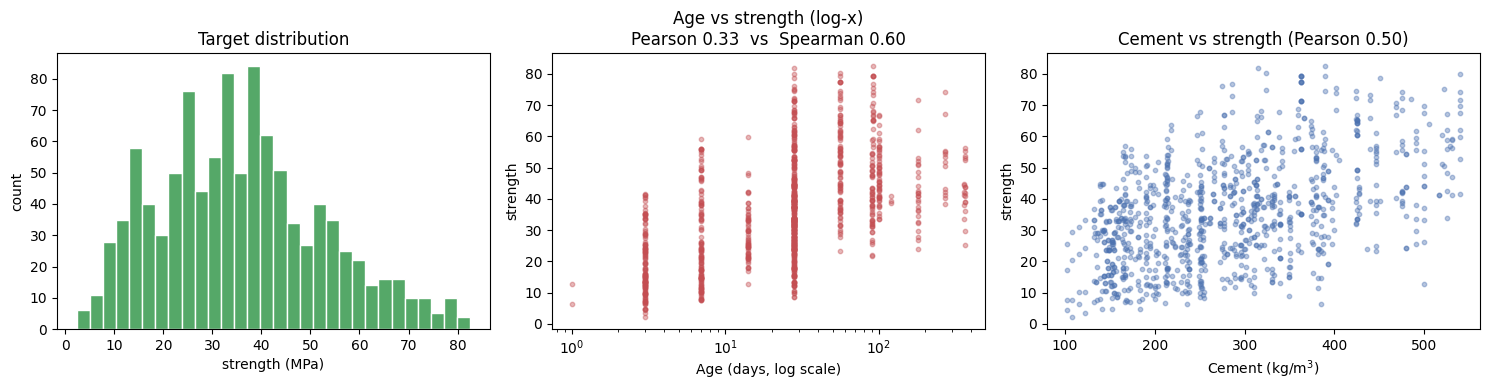

In [4]:
# ---------------- visualization ----------------
# (1) feature distribution grid -> zero-inflation & differing scales
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), conc_X.columns):
    ax.hist(conc_X[c], bins=30, color="#4c72b0", edgecolor="white")
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=8)
fig.suptitle("Concrete: feature distributions (note zero-spikes in Slag / Fly Ash / Superplasticizer)", y=1.02)
plt.tight_layout(); plt.show()

# (2) target + Age (log-x, non-linear) & Cement scatters vs strength
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(t, bins=30, color="#55a868", edgecolor="white")
axes[0].set_title("Target distribution"); axes[0].set_xlabel("strength (MPa)"); axes[0].set_ylabel("count")
axes[1].scatter(conc_X["Age"], t, s=10, alpha=0.4, color="#c44e52")
axes[1].set_xscale("log")
axes[1].set_title(f"Age vs strength (log-x)\nPearson {corr.loc['Age','pearson']:.2f}  vs  Spearman {corr.loc['Age','spearman']:.2f}")
axes[1].set_xlabel("Age (days, log scale)"); axes[1].set_ylabel("strength")
axes[2].scatter(conc_X["Cement"], t, s=10, alpha=0.4, color="#4c72b0")
axes[2].set_title(f"Cement vs strength (Pearson {corr.loc['Cement','pearson']:.2f})")
axes[2].set_xlabel("Cement (kg/m$^3$)"); axes[2].set_ylabel("strength")
plt.tight_layout(); plt.show()

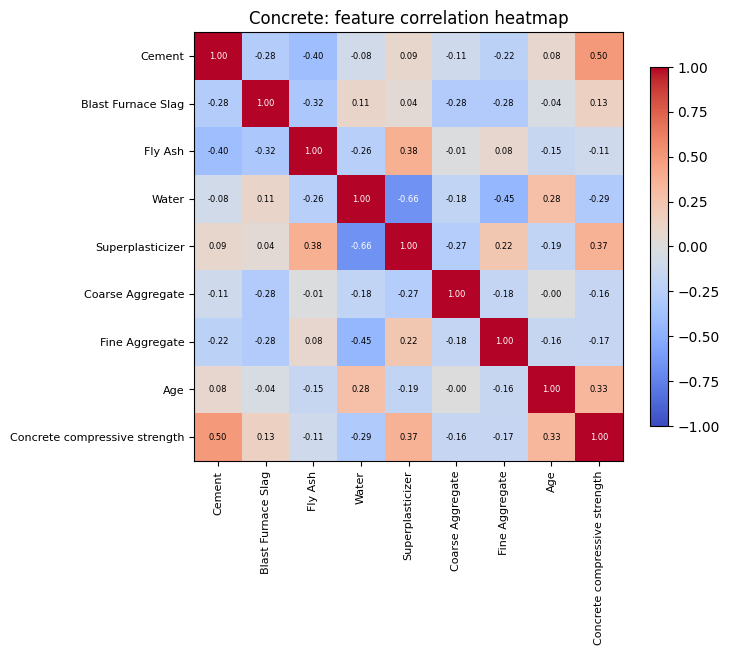

In [5]:
# (3) feature-feature correlation heatmap -> multicollinearity
fig, ax = plt.subplots(figsize=(7.5, 6.5))
cm = pd.concat([conc_X, t], axis=1).corr()
im = ax.imshow(cm, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns, fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(cm.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Concrete: feature correlation heatmap")
plt.tight_layout(); plt.show()


#### Diagnose Concrete data-quality issues

In [6]:
# ---- Task 1.3  Concrete: cleaning rationale — show the issues, THEN clean ----
full_c = pd.concat([conc_X, conc_y], axis=1)

# (A) ISSUE — missing? none -> no imputation/interpolation needed. And the many zeros are
#     STRUCTURAL ("component not used in the mix"), NOT missing, so they are kept as 0.
print(f"missing values: {int(conc_X.isna().sum().sum())} (none)  -> no interpolation/imputation needed")
zp = (conc_X == 0).mean().mul(100).round(1)
print(f"exact-zero %: {zp[zp > 0].to_dict()}  -> structural ('component not used in mix'), KEEP as 0\n")

# (B) ISSUE — duplicates. Separate leakage artifacts from legitimate repeat tests.
same_mix_var = int(full_c.groupby(list(conc_X.columns))[conc_target].nunique().gt(1).sum())
print(f"duplicates: feature-only={int(conc_X.duplicated().sum())}  "
      f"full-row(X+y)={int(full_c.duplicated().sum())}  mixes-with->1-strength={same_mix_var}")
print("-> DECISION: DROP full-row exact dups (byte-identical continuous rows = same physical "
      "record = train/test leakage); KEEP same-mix / different-strength rows (real repeat tests).")


missing values: 0 (none)  -> no interpolation/imputation needed
exact-zero %: {'Blast Furnace Slag': 45.7, 'Fly Ash': 55.0, 'Superplasticizer': 36.8}  -> structural ('component not used in mix'), KEEP as 0

duplicates: feature-only=38  full-row(X+y)=25  mixes-with->1-strength=9
-> DECISION: DROP full-row exact dups (byte-identical continuous rows = same physical record = train/test leakage); KEEP same-mix / different-strength rows (real repeat tests).


#### Apply the Concrete cleaning (drop leakage duplicates)

In [7]:
# ---- Task 1.3  Concrete: apply cleaning (based on the diagnosis above) ----
# Zeros are structural -> KEEP. Drop only FULL-ROW exact duplicates (leakage artifacts);
# keep same-mix / different-strength rows (legitimate repeat tests).
full_c = pd.concat([conc_X, conc_y], axis=1)
n_full_dup = int(full_c.duplicated().sum())

full_c_dedup = full_c.drop_duplicates().reset_index(drop=True)
conc_X_clean = full_c_dedup[conc_X.columns].copy()
conc_y_clean = full_c_dedup[conc_target].copy()

print(f"dropped {n_full_dup} full-row exact duplicates (leakage artifacts)")
print(f"legitimate feature-duplicate rows remaining (same mix, different strength): "
      f"{int(conc_X_clean.duplicated().sum())}")
assert conc_X_clean.isna().sum().sum() == 0
print(f"\nConcrete cleaned:  X={conc_X_clean.shape}  y={conc_y_clean.shape}")
display(conc_X_clean.head())


dropped 25 full-row exact duplicates (leakage artifacts)
legitimate feature-duplicate rows remaining (same mix, different strength): 13

Concrete cleaned:  X=(1005, 8)  y=(1005,)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


#### Multicollinearity check (drop correlated features)

In [8]:
# ---- Task 1.4  Concrete: multicollinearity check — drop one of any highly-correlated pair ----
# Diagnosed visually by the correlation heatmap above. Fixed rule applied BEFORE the split (leak-free):
# for every feature pair with |Pearson r| > CORR_THR, drop the one LESS correlated with the target
# (keep the more predictive feature). Redundant collinear inputs inflate linear-model variance.
CORR_THR = 0.85
_corr  = conc_X_clean.corr().abs()
_tcorr = conc_X_clean.corrwith(conc_y_clean).abs()   # |corr| of each feature with the target

drop_cols, pairs = set(), []
cols = list(conc_X_clean.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]; r = _corr.loc[a, b]
        if r > CORR_THR:
            loser = a if _tcorr[a] < _tcorr[b] else b   # drop the weaker-vs-target feature
            pairs.append((a, b, r, loser)); drop_cols.add(loser)

print(f"Multicollinearity check (|Pearson r| > {CORR_THR}):")
if pairs:
    for a, b, r, loser in pairs:
        print(f"  {a} <-> {b}:  |r|={r:.2f}  -> drop '{loser}' (weaker target corr)")
else:
    print("  no feature pair exceeds the threshold -> nothing to drop")
_off = _corr.where(~np.eye(len(_corr), dtype=bool)).stack()   # largest off-diagonal |r|, for context
_amax = _off.idxmax()
print(f"  (strongest inter-feature correlation observed: |r|={_off.max():.2f}  between {_amax[0]} & {_amax[1]})")

conc_X_clean = conc_X_clean.drop(columns=list(drop_cols))
print(f"\ndropped {len(drop_cols)} feature(s): {sorted(drop_cols) if drop_cols else 'none'}")
print(f"Concrete features kept: {conc_X_clean.shape[1]}  {list(conc_X_clean.columns)}")


Multicollinearity check (|Pearson r| > 0.85):
  no feature pair exceeds the threshold -> nothing to drop
  (strongest inter-feature correlation observed: |r|=0.65  between Water & Superplasticizer)

dropped 0 feature(s): none
Concrete features kept: 8  ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


#### Held-out test split + 10-fold CV

In [9]:
# ---- Task 1.4  Concrete: held-out test + 10-fold CV (scikit-learn splitters) ----
def make_folds(y, k=10, stratify=False, seed=42):
    """List of (train_idx, val_idx) positional index pairs into the dev arrays (sklearn KFold splitters)."""
    splitter = (StratifiedKFold(n_splits=k, shuffle=True, random_state=seed) if stratify
                else KFold(n_splits=k, shuffle=True, random_state=seed))
    return list(splitter.split(np.zeros(len(y)), np.asarray(y)))

SEED, K = 42, 10
conc_Xdev, conc_Xte, conc_ydev, conc_yte = train_test_split(
    conc_X_clean, conc_y_clean, test_size=0.20, random_state=SEED, shuffle=True)
conc_folds = make_folds(conc_ydev, k=K, stratify=False, seed=SEED)

print(f"Concrete:  dev={conc_Xdev.shape}  test={conc_Xte.shape}   ({K}-fold CV on dev)")
print(f"  dev mean strength {np.asarray(conc_ydev).mean():.2f}  |  test mean strength {np.asarray(conc_yte).mean():.2f}")
print(f"  val fold size ~{len(conc_folds[0][1])}")


Concrete:  dev=(804, 8)  test=(201, 8)   (10-fold CV on dev)
  dev mean strength 35.07  |  test mean strength 35.98
  val fold size ~81


### Task 2: Implement baseline model of your choice (1 classification + 1 regression) for each of the two datasets. Please note you cannot use models required in Task 4 as baselines.

```python
baseline = YourAlgorithm()
baseline.learn(features_train, labels_train)
```

#### Load the regression baseline model & metrics from `mlab`

*Loads the Ridge/linear regression model and the regression metrics (R², MAE, RMSE) used by the Concrete task; reuses the loader set up for the classification models above.*

In [10]:
# ---- Task 2: load the regression baseline (Ridge/linear) + regression metrics from the mlab library ----
# Each library folder defines its own top-level `mlab`, so we load the needed files by path.
import sys, importlib.util, pathlib

def _find_libs():
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        for cand in (base / "libraries" / "mlab", base / "final-assignment" / "libraries" / "mlab",
                     base / "libraries", base / "final-assignment" / "libraries"):
            if (cand / "MLRegKit").exists() and (cand / "logitlab").exists():
                return cand
    raise FileNotFoundError("Could not locate final-assignment/libraries/")
LIBS = _find_libs()

def _load_mlab(name, relpath):
    spec = importlib.util.spec_from_file_location(name, LIBS / relpath)
    mod = importlib.util.module_from_spec(spec); sys.modules[name] = mod
    spec.loader.exec_module(mod); return mod

_linear_mod = _load_mlab("mlab_linear", "MLRegKit/mlab/regression/_linear.py")
_reg_metrics = _load_mlab("mlab_reg_metrics", "MLRegKit/mlab/regression/metrics.py")

LinearRegression = _linear_mod.LinearRegression   # Ridge (closed-form); no internal scaling
reg = _reg_metrics                                # r2_score / mae / rmse
print("Loaded regression baseline (LinearRegression/Ridge) + metrics (R2 / MAE / RMSE)")


Loaded regression baseline (LinearRegression/Ridge) + metrics (R2 / MAE / RMSE)


#### Leak-free k-fold cross-validation helper

*Defines the leak-free k-fold cross-validation helper (the scaler is fit inside each fold).*

In [11]:
def cv_report(Xdev, ydev, folds, make_model, metrics, scale=True, report_train=False):
    """k-fold CV. If scale=True, fit a StandardScaler INSIDE each fold (leak-free) before the model;
    use scale=False for models that standardize internally (SVM / ANN). Returns {metric: (mean, std)}.
    With report_train=True, also returns 'train_<metric>' keys (scored on the TRAIN fold) so the
    train-vs-validation gap can be inspected as an overfitting check."""
    Xv = Xdev.values if hasattr(Xdev, "values") else np.asarray(Xdev)
    yv = np.asarray(ydev)
    acc    = {m: [] for m in metrics}
    acc_tr = {m: [] for m in metrics}
    for tr, val in folds:
        if scale:
            sc = StandardScaler().fit(Xv[tr]); Xtr, Xval = sc.transform(Xv[tr]), sc.transform(Xv[val])
        else:
            Xtr, Xval = Xv[tr], Xv[val]
        model = make_model().fit(Xtr, yv[tr])
        pred = np.asarray(model.predict(Xval)).ravel()
        for m, fn in metrics.items():
            acc[m].append(fn(yv[val], pred))
        if report_train:
            pred_tr = np.asarray(model.predict(Xtr)).ravel()
            for m, fn in metrics.items():
                acc_tr[m].append(fn(yv[tr], pred_tr))
    out = {m: (float(np.mean(v)), float(np.std(v))) for m, v in acc.items()}
    if report_train:
        out.update({f"train_{m}": (float(np.mean(v)), float(np.std(v))) for m, v in acc_tr.items()})
    return out

print("Loaded mlab baselines + metrics + CV helper from:", LIBS)


Loaded mlab baselines + metrics + CV helper from: /home/mohamed-osman/Documents/Machine Learning Lab/final-assignment/libraries/mlab


#### Baseline — Ridge Regression (CV + final fit)

In [12]:
# ---- Task 2  Concrete baseline: LinearRegression/Ridge — 10-fold CV on the dev set ----
conc_metrics = {"R2": reg.r2_score, "MAE": reg.mae, "RMSE": reg.rmse}
conc_cv = cv_report(conc_Xdev, conc_ydev, conc_folds,
                    lambda: LinearRegression(alpha=0.1), conc_metrics)

print("Concrete — LinearRegression/Ridge (alpha=0.1)  |  10-fold CV on dev:")
for m, (mu, sd) in conc_cv.items():
    unit = "" if m == "R2" else " MPa"
    print(f"  {m:4s}: {mu:.3f} ± {sd:.3f}{unit}")

# fit the FINAL model on the full dev set (used for the held-out test evaluation in Task 3)
conc_scaler   = StandardScaler().fit(conc_Xdev.values)
conc_baseline = LinearRegression(alpha=0.1).fit(
    conc_scaler.transform(conc_Xdev.values), np.asarray(conc_ydev))


Concrete — LinearRegression/Ridge (alpha=0.1)  |  10-fold CV on dev:
  R2  : 0.585 ± 0.071
  MAE : 8.090 ± 0.564 MPa
  RMSE: 10.144 ± 0.709 MPa


### Task 3: Evaluate your baseline models on test set: 
Use accuracy, precision and recall for classification, and R2 score and MAE/RMSE for regression
```python
baseline_predicted = model_baseline.infer(features_test)
evaluate_fn(baseline_predicted, labels_test)
```

#### Evaluate the Ridge baseline on the test set

In [13]:
# ---- Task 3  Concrete: evaluate the final baseline on the held-out TEST set ----
yte_c = np.asarray(conc_yte)
conc_pred = conc_baseline.predict(conc_scaler.transform(conc_Xte.values))
r2v, maev, rmsev = reg.r2_score(yte_c, conc_pred), reg.mae(yte_c, conc_pred), reg.rmse(yte_c, conc_pred)

print(f"Concrete — LinearRegression/Ridge baseline  (TEST, n={len(yte_c)})   [test vs 10-fold CV]")
print(f"  R2  : {r2v:.3f}   (CV {conc_cv['R2'][0]:.3f} ± {conc_cv['R2'][1]:.3f})")
print(f"  MAE : {maev:.2f} MPa   (CV {conc_cv['MAE'][0]:.2f} ± {conc_cv['MAE'][1]:.2f})")
print(f"  RMSE: {rmsev:.2f} MPa   (CV {conc_cv['RMSE'][0]:.2f} ± {conc_cv['RMSE'][1]:.2f})")


Concrete — LinearRegression/Ridge baseline  (TEST, n=201)   [test vs 10-fold CV]
  R2  : 0.580   (CV 0.585 ± 0.071)
  MAE : 8.90 MPa   (CV 8.09 ± 0.56)
  RMSE: 11.19 MPa   (CV 10.14 ± 0.71)


### Task 4: Implement and train the following methods:

    a) SVM with any non-linear kernel for classification 
    b) ANN for regression
    
- Use one fixed train-validation-test split consistently for all experiments
- Report the same metrics used for the baselines on the test set.

#### Load the ANN (MLPRegressor) from `mlab`

*Loads the neural-network regressor used for the Concrete regression task.*

In [14]:
# ---- Load the ANN (MLPRegressor) for the Concrete regression task ----
# neurokit's _mlp.py is self-contained (numpy) -> load by path like the baselines.
_mlp_mod = _load_mlab("mlab_mlp", "neurokit/mlab/neural_networks/_mlp.py")
MLPRegressor = _mlp_mod.MLPRegressor
ANN_EPOCHS = 300   # shared across the ANN CV / grid / stability cells for consistency
print("Loaded ANN:", MLPRegressor.__name__)

Loaded ANN: MLPRegressor


#### ANN (MLP regressor) — CV + test evaluation

In [15]:
# ---- Task 4b  Concrete: ANN (MLPRegressor) — 10-fold CV + held-out test ----
# The ANN standardizes X and y internally, so we pass RAW features (scale=False).
def make_mlp():
    return MLPRegressor(hidden_layer_sizes=(64, 32), lr=0.01, epochs=ANN_EPOCHS,
                        alpha=1e-4, activation="relu", random_state=SEED)

ann_cv = cv_report(conc_Xdev, conc_ydev, conc_folds, make_mlp, conc_metrics, scale=False)
print("Concrete — ANN (MLPRegressor 64-32, relu)  |  10-fold CV on dev:")
for m, (mu, sd) in ann_cv.items():
    unit = "" if m == "R2" else " MPa"
    print(f"  {m:4s}: {mu:.3f} ± {sd:.3f}{unit}   (linear baseline CV {conc_cv[m][0]:.3f})")

# final model on full dev -> held-out test
conc_ann = make_mlp().fit(conc_Xdev.values, np.asarray(conc_ydev))
ann_pred = np.asarray(conc_ann.predict(conc_Xte.values)).ravel()
print(f"\nConcrete — ANN  (TEST, n={len(yte_c)}):")
print(f"  R2  : {reg.r2_score(yte_c, ann_pred):.3f}   (linear baseline {r2v:.3f})")
print(f"  MAE : {reg.mae(yte_c, ann_pred):.2f} MPa   (linear baseline {maev:.2f})")
print(f"  RMSE: {reg.rmse(yte_c, ann_pred):.2f} MPa   (linear baseline {rmsev:.2f})")


Concrete — ANN (MLPRegressor 64-32, relu)  |  10-fold CV on dev:
  R2  : 0.845 ± 0.041   (linear baseline CV 0.585)
  MAE : 4.710 ± 0.353 MPa   (linear baseline CV 8.090)
  RMSE: 6.141 ± 0.443 MPa   (linear baseline CV 10.144)

Concrete — ANN  (TEST, n=201):
  R2  : 0.861   (linear baseline 0.580)
  MAE : 4.78 MPa   (linear baseline 8.90)
  RMSE: 6.43 MPa   (linear baseline 11.19)


### Task 5: Hyperparameter Optimisation
- For each of the models implemented in Task 4, conduct a grid search in reasonable ranges to find an appropriate set of hyperparameters, and justify the choice.

```python
possible_hp_values = np.arange(1, 10, 0.1)
best_hp_value = None
best_f1_score = -np.infty
for hp_value in possible_hp_values:
    # 1. create a baseline classifier object with hp_value specified
    current_model = YourAlgorithm(hyperparam=hp_value)
    
    # 2. learn the classifier on the training set
    current_model.learn(features_train, labels_train)
    
    # 3. evaluate the model on the validation set
    prediction = current_model.infer(features_valid)
    
    f1_score = compute_f1(labels_valid, prediction)
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_hp_value = hp_value

print("Found hyperparameter value", best_hp_value)
print("Best f1-score on validation set", best_f1_score)

test_model = YourAlgorithm(hyperparam=best_hp_value)
test_model.learn(features_train, labels_train)
prediction = test_model.infer(features_test)
test_f1_score = compute_f1(labels_test, prediction)
print("F1-Score on test set", test_f1_score)
```

#### Generic grid-search helper (used by the ANN grid)

*A small cross-validated grid-search utility reused by the Concrete ANN hyperparameter search below.*

In [16]:
# ---- Generic CV grid-search helper (reused by the Concrete ANN grid below) ----
import itertools
def grid_search(Xdev, ydev, folds, model_from, param_grid, select_metric, metrics, scale):
    keys = list(param_grid); results = []
    for combo in itertools.product(*[param_grid[k] for k in keys]):
        params = dict(zip(keys, combo))
        cvres = cv_report(Xdev, ydev, folds, (lambda p=params: model_from(**p)), metrics, scale=scale)
        results.append((params, cvres))
    best = max(results, key=lambda r: r[1][select_metric][0])
    return best, results
print("grid_search ready")

grid_search ready


#### ANN hyperparameter grid search (architecture, lr)

In [17]:
# ---- Task 5b  Concrete ANN: 10-fold CV grid search over architecture & learning rate ----
ann_grid = {"hidden_layer_sizes": [(32,), (64, 32), (128, 64)], "lr": [0.01, 0.05]}
def mlp_from(**p):
    return MLPRegressor(alpha=1e-4, epochs=ANN_EPOCHS, activation="relu", random_state=SEED, **p)

(ann_best, ann_best_cv), ann_results = grid_search(
    conc_Xdev, conc_ydev, conc_folds, mlp_from, ann_grid, select_metric="R2", metrics=conc_metrics, scale=False)

print(f"ANN grid: {len(ann_results)} combos x {K}-fold CV, ranked by CV R2:")
for params, cvres in sorted(ann_results, key=lambda r: -r[1]['R2'][0]):
    print(f"  hidden={str(params['hidden_layer_sizes']):<10} lr={params['lr']:<5} -> R2={cvres['R2'][0]:.3f}  RMSE={cvres['RMSE'][0]:.2f}")
print(f"\nChosen ANN: {ann_best}   (CV R2 {ann_best_cv['R2'][0]:.3f} ± {ann_best_cv['R2'][1]:.3f})")

# refit the chosen ANN on the full dev set -> evaluate once on the held-out test
conc_ann_tuned = mlp_from(**ann_best).fit(conc_Xdev.values, np.asarray(conc_ydev))
pa = np.asarray(conc_ann_tuned.predict(conc_Xte.values)).ravel()
print(f"\nConcrete — TUNED ANN  (TEST, n={len(yte_c)}):")
print(f"  R2 {reg.r2_score(yte_c,pa):.3f} | MAE {reg.mae(yte_c,pa):.2f} MPa | RMSE {reg.rmse(yte_c,pa):.2f} MPa")
print(f"  reference test R2 -> default ANN {reg.r2_score(yte_c, ann_pred):.3f} | linear baseline {r2v:.3f}")


ANN grid: 6 combos x 10-fold CV, ranked by CV R2:
  hidden=(64, 32)   lr=0.01  -> R2=0.845  RMSE=6.14
  hidden=(32,)      lr=0.01  -> R2=0.843  RMSE=6.22
  hidden=(128, 64)  lr=0.01  -> R2=0.840  RMSE=6.27
  hidden=(128, 64)  lr=0.05  -> R2=0.699  RMSE=8.63
  hidden=(32,)      lr=0.05  -> R2=0.681  RMSE=8.91
  hidden=(64, 32)   lr=0.05  -> R2=0.680  RMSE=8.88

Chosen ANN: {'hidden_layer_sizes': (64, 32), 'lr': 0.01}   (CV R2 0.845 ± 0.041)

Concrete — TUNED ANN  (TEST, n=201):
  R2 0.861 | MAE 4.78 MPa | RMSE 6.43 MPa
  reference test R2 -> default ANN 0.861 | linear baseline 0.580


### Task 6: Statistical/stability tests

- over multiple runs $r \geq 5, r\in\mathbb{N}$  randomly shuffle your training data
- split it into a train-test, e.g. 90% of the data is for training, 10% for testing
- Report the mean and standard deviation of the error/accuracy of your models over the multiple runs
- plot a boxplot of the stability of your model

#### Stability test — the resampling harness (20 × 90/10)

*Defines the stability harness: repeatedly reshuffle, take a 90/10 split, fit, and score.*

In [18]:
# ---- Task 6  Breast Cancer: stability over R shuffled 90/10 train-test runs ----
# Compares the BASELINE logistic (mlab balanced weights, default 0.5 threshold) against the required SVM.
# The SVM oversamples its TRAIN split and uses a PRIOR-MATCHED cut (its uncalibrated, bias-free margins mean
# an absolute threshold would not transfer) -- necessary for the kernel SVM, not a baseline tweak.
# This 20-run mean +/- std is the honest primary estimate; the single held-out test is one noisy draw.
RUNS = 20
def stability_runs(X, y, model_from, metric_fns, scale, runs=RUNS, test_frac=0.10, seed0=100,
                   stratify=False, predict_fn=None):
    """Re-shuffle -> 90/10 split -> fit -> score, `runs` times. Returns {metric: [per-run scores]}.
    predict_fn(Xtr, ytr, Xte, seed) overrides the default fit/predict (threshold tuning / oversampling)."""
    Xv = X.values if hasattr(X, "values") else np.asarray(X); yv = np.asarray(y); n = len(yv)
    out = {m: [] for m in metric_fns}
    for r in range(runs):
        rng = np.random.default_rng(seed0 + r)
        if stratify:
            te_parts = []
            for c in np.unique(yv):
                ci = np.where(yv == c)[0]; rng.shuffle(ci)
                te_parts.append(ci[:int(round(test_frac * len(ci)))])
            te = np.concatenate(te_parts); tr = np.setdiff1d(np.arange(n), te); rng.shuffle(tr)
        else:
            idx = rng.permutation(n); nte = int(round(test_frac * n)); te, tr = idx[:nte], idx[nte:]
        Xtr, Xte = Xv[tr], Xv[te]
        if scale:
            sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        if predict_fn is not None:
            pred = np.asarray(predict_fn(Xtr, yv[tr], Xte, seed0 + r)).ravel()
        else:
            pred = np.asarray(model_from().fit(Xtr, yv[tr]).predict(Xte)).ravel()
        for m, fn in metric_fns.items():
            out[m].append(fn(yv[te], pred))
    return out


#### Stability test — Concrete (20 runs)

Concrete — stability over 20 shuffled 90/10 runs (mean ± std):
  Linear baseline  R2 0.605 ± 0.070  |  RMSE 10.16 ± 0.63 MPa
  ANN (tuned)      R2 0.851 ± 0.044  |  RMSE 6.19 ± 0.61 MPa


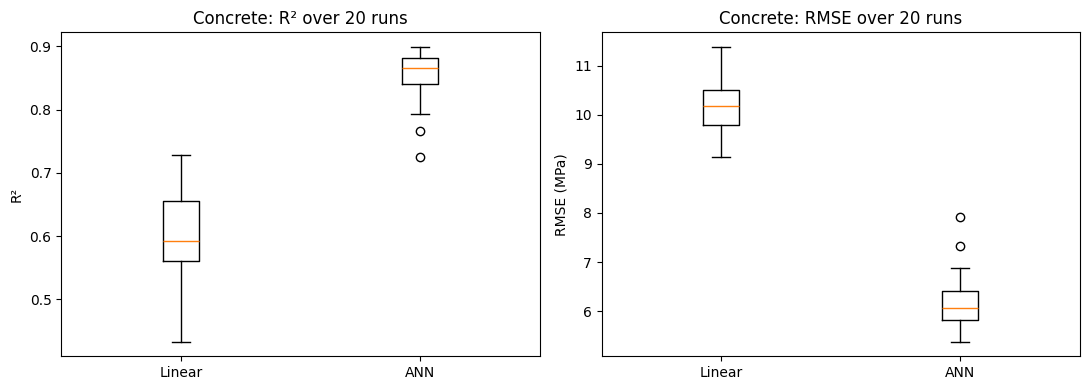

In [19]:
# ---- Task 6  Concrete: stability over R shuffled 90/10 train-test runs ----
reg_stab_metrics = {"R2": reg.r2_score, "RMSE": reg.rmse}
conc_lin_stab = stability_runs(conc_X_clean, conc_y_clean,
    lambda: LinearRegression(alpha=0.1), reg_stab_metrics, scale=True)
conc_ann_stab = stability_runs(conc_X_clean, conc_y_clean,
    lambda: MLPRegressor(hidden_layer_sizes=(64, 32), lr=0.01, epochs=ANN_EPOCHS, alpha=1e-4,
                         activation="relu", random_state=SEED), reg_stab_metrics, scale=False)

print(f"Concrete — stability over {RUNS} shuffled 90/10 runs (mean ± std):")
for name, st in [("Linear baseline", conc_lin_stab), ("ANN (tuned)", conc_ann_stab)]:
    print(f"  {name:16s} R2 {np.mean(st['R2']):.3f} ± {np.std(st['R2']):.3f}  |  "
          f"RMSE {np.mean(st['RMSE']):.2f} ± {np.std(st['RMSE']):.2f} MPa")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([conc_lin_stab['R2'], conc_ann_stab['R2']], tick_labels=['Linear', 'ANN'])
ax[0].set_title(f"Concrete: R² over {RUNS} runs"); ax[0].set_ylabel("R²")
ax[1].boxplot([conc_lin_stab['RMSE'], conc_ann_stab['RMSE']], tick_labels=['Linear', 'ANN'])
ax[1].set_title(f"Concrete: RMSE over {RUNS} runs"); ax[1].set_ylabel("RMSE (MPa)")
plt.tight_layout(); plt.show()
